# 01 — EDA & Nettoyage : customers.csv

*Notebook*

> **Dépendances :** Premier notebook de la série. Autonome : charge et nettoie `customers.csv` depuis zéro.


# **Exploratory Data Analysis (EDA) & Data Cleaning — H&M Dataset**

---



## Dataset: customers.csv

---



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configuration des graphiques
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

sns.set_palette("husl")

## 0. Configuration de l'environnement (Google Colab + Google Drive)

Ce notebook est conçu pour être exécuté sur **Google Colab**, avec les fichiers du dataset
(`customers.csv`, `articles.csv`, `transactions_train.csv`) stockés sur **Google Drive**.

Adapte simplement `BASE_PATH` ci-dessous à l'emplacement réel de tes fichiers sur ton Drive
(clic droit sur le dossier dans Drive -> "Copier le chemin d'accès").


In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # --- À adapter selon l'emplacement réel de tes fichiers sur Google Drive ---
    BASE_PATH = "/content/drive/MyDrive/HM_dataset/"
except ImportError:
    # Environnement hors Colab (ex. exécution locale/test) : fichiers dans le dossier courant
    print("Google Colab non détecté -> lecture des fichiers dans le dossier courant.")
    BASE_PATH = "./"

import os

CUSTOMERS_PATH = os.path.join(BASE_PATH, "customers.csv")
ARTICLES_PATH = os.path.join(BASE_PATH, "articles.csv")
TRANSACTIONS_PATH = os.path.join(BASE_PATH, "transactions_train.csv")
SAMPLE_SUBMISSION_PATH = os.path.join(BASE_PATH, "sample_submission.csv")

for name, p in [("customers", CUSTOMERS_PATH), ("articles", ARTICLES_PATH),
                ("transactions_train", TRANSACTIONS_PATH)]:
    print(f"{name:20s} -> {'trouvé' if os.path.exists(p) else 'INTROUVABLE'} ({p})")


Mounted at /content/drive
customers            -> trouvé (/content/drive/MyDrive/HM_dataset/customers.csv)
articles             -> trouvé (/content/drive/MyDrive/HM_dataset/articles.csv)
transactions_train   -> trouvé (/content/drive/MyDrive/HM_dataset/transactions_train.csv)


In [4]:
# Chargement des données
df = pd.read_csv(CUSTOMERS_PATH)

print("="*60)
print("APERÇU GÉNÉRAL DU DATASET")
print("="*60)
print(f"Dimensions du dataset: {df.shape}")
print(f"Nombre total de cellules: {df.shape[0] * df.shape[1]:,}")
print()

APERÇU GÉNÉRAL DU DATASET
Dimensions du dataset: (1371980, 7)
Nombre total de cellules: 9,603,860



In [5]:
# Informations générales
print("INFORMATIONS GÉNÉRALES:")
print("-" * 30)
df.info()
print()

INFORMATIONS GÉNÉRALES:
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371980 entries, 0 to 1371979
Data columns (total 7 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1371980 non-null  object 
 1   FN                      476930 non-null   float64
 2   Active                  464404 non-null   float64
 3   club_member_status      1365918 non-null  object 
 4   fashion_news_frequency  1355969 non-null  object 
 5   age                     1356119 non-null  float64
 6   postal_code             1371980 non-null  object 
dtypes: float64(3), object(4)
memory usage: 73.3+ MB



In [6]:
# Aperçu des premières lignes
print("APERÇU DES DONNÉES:")
print("-" * 30)
print(df.head())
print()

APERÇU DES DONNÉES:
------------------------------
                                         customer_id   FN  Active  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...  NaN     NaN   
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...  NaN     NaN   
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...  NaN     NaN   
3  00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...  NaN     NaN   
4  00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...  1.0     1.0   

  club_member_status fashion_news_frequency   age  \
0             ACTIVE                   NONE  49.0   
1             ACTIVE                   NONE  25.0   
2             ACTIVE                   NONE  24.0   
3             ACTIVE                   NONE  54.0   
4             ACTIVE              Regularly  52.0   

                                         postal_code  
0  52043ee2162cf5aa7ee79974281641c6f11a68d276429a...  
1  2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...  
2  64f17e6a330a85798e4998f62d0930d14db8db1c054af6.

In [7]:
# Statistiques descriptives de base
print("STATISTIQUES DESCRIPTIVES - VARIABLES NUMÉRIQUES:")
print("-" * 50)
print(df.describe())

STATISTIQUES DESCRIPTIVES - VARIABLES NUMÉRIQUES:
--------------------------------------------------
             FN    Active           age
count  476930.0  464404.0  1.356119e+06
mean        1.0       1.0  3.638696e+01
std         0.0       0.0  1.431363e+01
min         1.0       1.0  1.600000e+01
25%         1.0       1.0  2.400000e+01
50%         1.0       1.0  3.200000e+01
75%         1.0       1.0  4.900000e+01
max         1.0       1.0  9.900000e+01


In [8]:
# ================================================================
# 2. ANALYSE DES DONNÉES MANQUANTES
# ================================================================

print("\n" + "="*60)
print("ANALYSE DES DONNÉES MANQUANTES")
print("="*60)

# Calcul des valeurs manquantes
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Colonnes': missing_data.index,
    'Valeurs_Manquantes': missing_data.values,
    'Pourcentage': missing_percent.values
}).sort_values('Pourcentage', ascending=False)

# Affichage des colonnes avec des valeurs manquantes
missing_cols = missing_df[missing_df['Valeurs_Manquantes'] > 0]
print(f"Nombre de colonnes avec des valeurs manquantes: {len(missing_cols)}")
print("\nColonnes avec le plus de valeurs manquantes:")
print(missing_cols.head(10))


ANALYSE DES DONNÉES MANQUANTES
Nombre de colonnes avec des valeurs manquantes: 5

Colonnes avec le plus de valeurs manquantes:
                 Colonnes  Valeurs_Manquantes  Pourcentage
2                  Active              907576    66.150819
1                      FN              895050    65.237831
4  fashion_news_frequency               16011     1.167000
5                     age               15861     1.156066
3      club_member_status                6062     0.441843


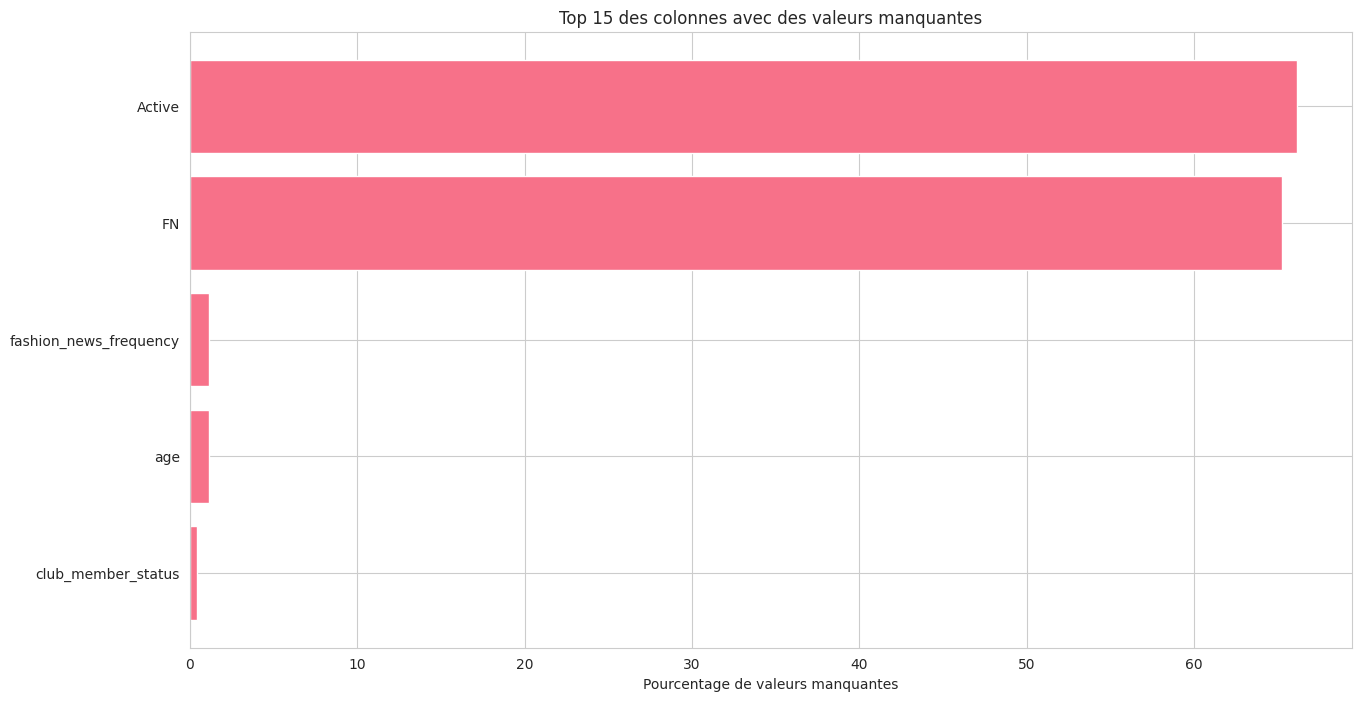

In [9]:
# Visualisation des données manquantes
plt.figure(figsize=(15, 8))
missing_cols_top = missing_cols.head(15)
plt.barh(missing_cols_top['Colonnes'], missing_cols_top['Pourcentage'])
plt.xlabel('Pourcentage de valeurs manquantes')
plt.title('Top 15 des colonnes avec des valeurs manquantes')
plt.gca().invert_yaxis()


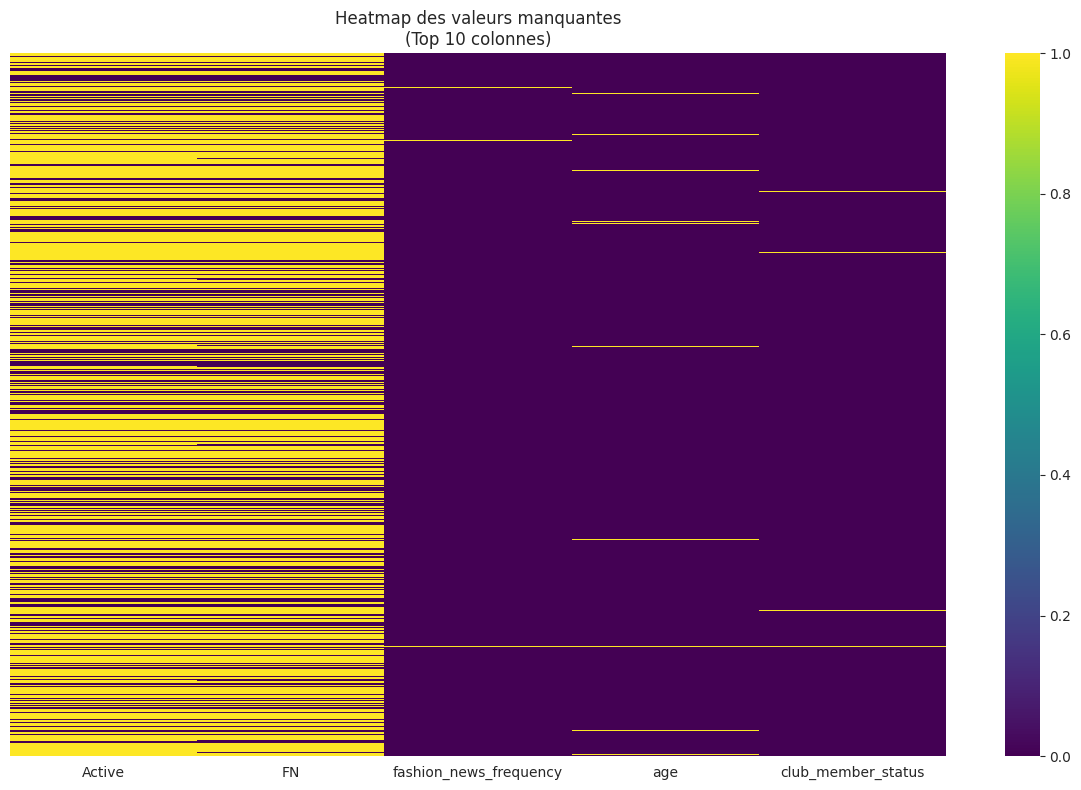

In [10]:
# Heatmap des valeurs manquantes (échantillon)
sample_cols = missing_cols.head(10)['Colonnes'].tolist()
if sample_cols:
    sns.heatmap(df[sample_cols].isnull(), cbar=True, yticklabels=False, cmap='viridis')
    plt.title('Heatmap des valeurs manquantes\n(Top 10 colonnes)')
plt.tight_layout()
plt.show()
plt.close('all')


In [11]:
# Suppression des colonnes très incomplètes
customers = df.drop(columns=["FN", "Active"])
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371980 entries, 0 to 1371979
Data columns (total 5 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1371980 non-null  object 
 1   club_member_status      1365918 non-null  object 
 2   fashion_news_frequency  1355969 non-null  object 
 3   age                     1356119 non-null  float64
 4   postal_code             1371980 non-null  object 
dtypes: float64(1), object(4)
memory usage: 52.3+ MB


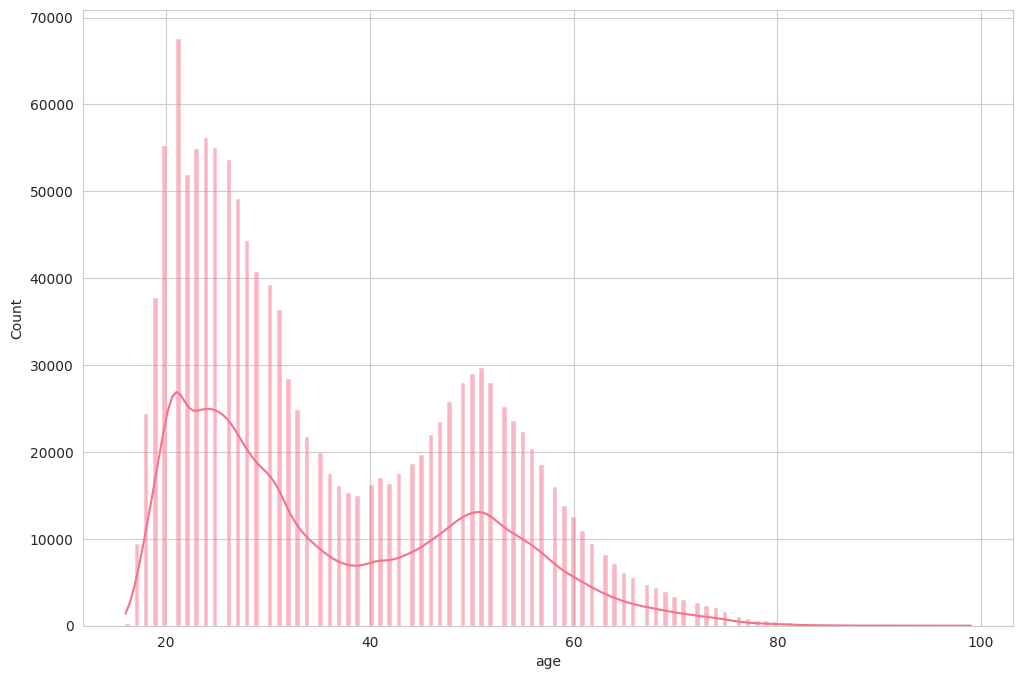

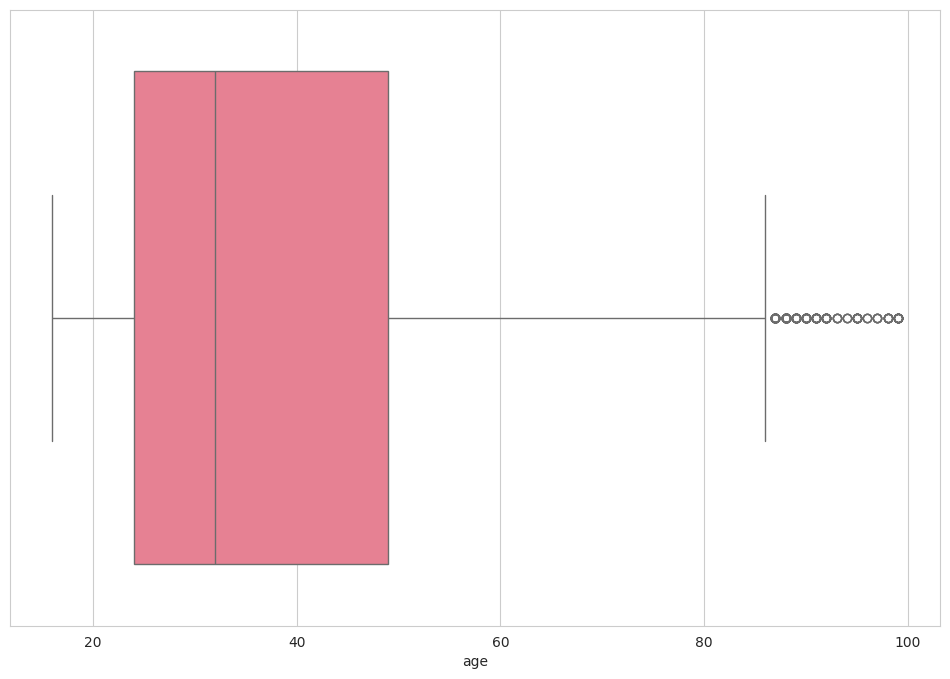

In [12]:
# Visualiser la distribution des variables
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["age"], kde=True)
plt.show()

sns.boxplot(x=df["age"])
plt.show()
plt.close('all')


<Axes: xlabel='club_member_status'>

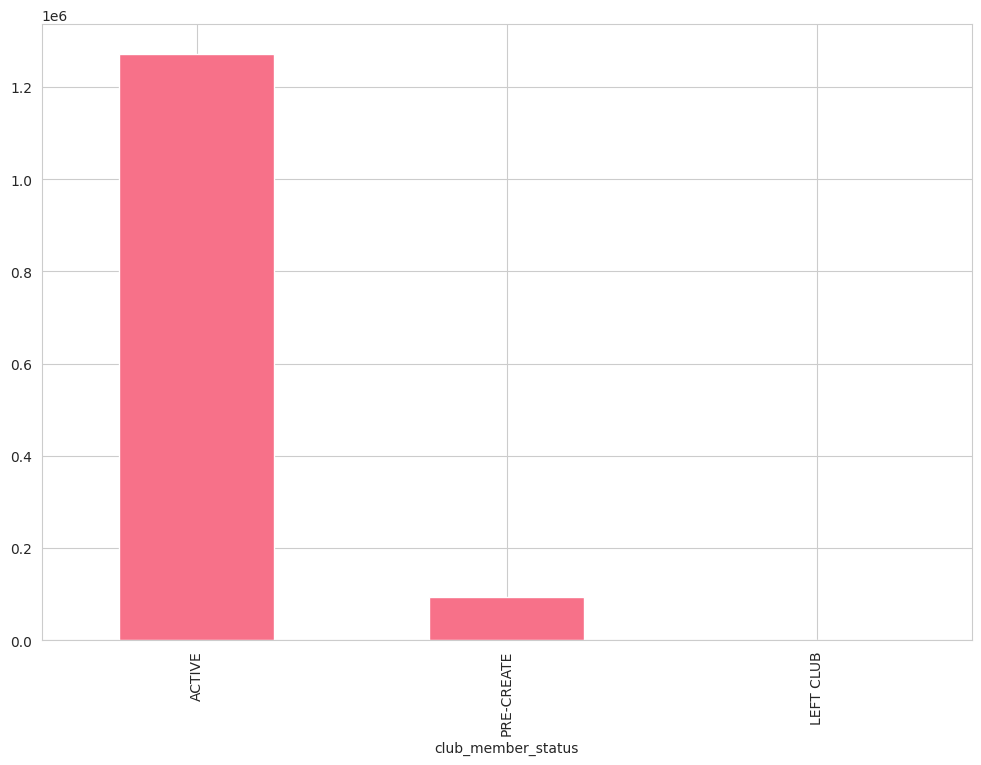

In [13]:
df["club_member_status"].value_counts().plot.bar()

In [14]:
# Tester la normalité (pour les variables numériques)
from scipy.stats import normaltest

x = df["age"].dropna()

stat, p = normaltest(x)

print(f"Statistic = {stat:.4f}")
print(f"p-value = {p:.4f}")

Statistic = 147656.3613
p-value = 0.0000


**Interprétation :**

- p > 0.05 : on ne rejette pas l'hypothèse que la distribution est normale.
- p < 0.05 : on rejette l'hypothèse de normalité.

> Le résultat du test doit être interprété conjointement avec les visualisations (histogramme et QQ-plot) ainsi que les mesures de skewness et de kurtosis, car les tests de normalité peuvent être très sensibles sur des jeux de données volumineux.

**Choix de l'imputation :**

- Distribution approximativement normale → imputation par la moyenne.
- Distribution asymétrique ou présence de valeurs aberrantes → imputation par la médiane.

| Test                   | Quand l'utiliser ?                                                             | Avantages                                                                 | Limites                                                                                           |
| ---------------------- | ------------------------------------------------------------------------------ | ------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------- |
| **Shapiro-Wilk**       | Petits à moyens échantillons (≈ jusqu'à 5 000 observations)                    | Très puissant pour détecter les écarts à la normalité                     | Peu adapté aux très grands échantillons                                                           |
| **D'Agostino-Pearson** | Grands échantillons (n ≥ 20, idéalement > 100)                                 | Combine skewness et kurtosis, très utilisé avec de grands jeux de données | Nécessite un échantillon suffisamment grand                                                       |
| **Anderson-Darling**   | Toutes tailles d'échantillon                                                   | Plus sensible dans les queues de distribution que KS                      | Ne fournit pas directement une p-valeur dans SciPy (mais une statistique et des seuils critiques) |
| **Kolmogorov-Smirnov** | Lorsque la distribution de référence est entièrement spécifiée                 | Simple à utiliser                                                         | Pas idéal lorsque les paramètres sont estimés à partir des données                                |
| **Lilliefors**         | Variante de KS lorsque la moyenne et l'écart-type sont estimés sur les données | Corrige la principale limite du KS classique                              | Pas disponible directement dans SciPy (disponible dans `statsmodels`)                             |


Le dataset contient près d'un million de clients. Pour la variable age, je recommanderais :

* Histogramme
* QQ-plot
* Skewness et éventuellement Kurtosis
* D'Agostino-Pearson (scipy.stats.normaltest)

Pourquoi ?

* il est conçu pour les grands échantillons
* il combine les informations sur l'asymétrie (skewness) et l'aplatissement (kurtosis)
* il est directement disponible dans SciPy.

In [15]:
# Mesurer l'asymétrie
df["age"].skew()

np.float64(0.6125926583459115)

**En général :**

- |skew| < 0.5 → distribution assez symétrique
- 0.5–1 → asymétrie modérée
- 1 → forte asymétrie

## 3.1 QQ-plot de la variable `age`

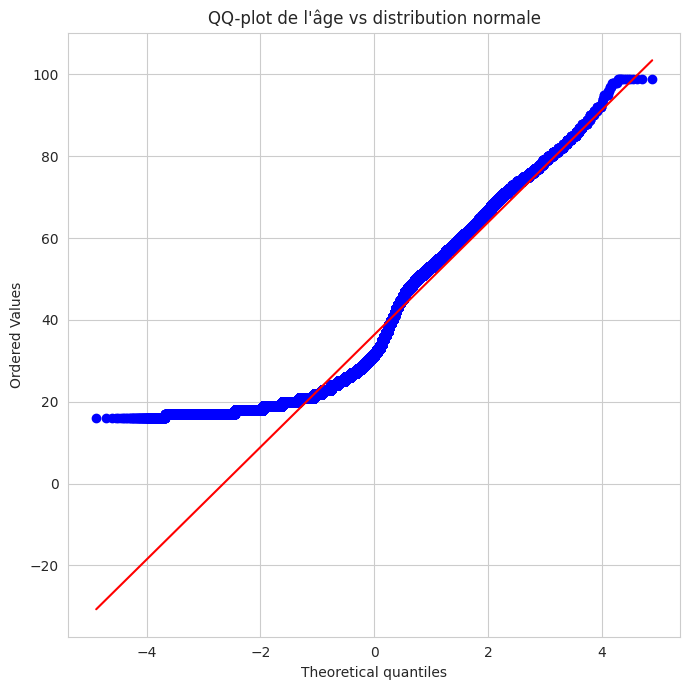

In [16]:
import scipy.stats as stats

fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(df["age"].dropna(), dist="norm", plot=ax)
ax.set_title("QQ-plot de l'âge vs distribution normale")
plt.tight_layout()
plt.show()
plt.close('all')


Sur le QQ-plot, les points s'écartent clairement de la droite de référence (surtout dans la queue
supérieure), ce qui confirme visuellement que `age` n'est **pas** distribuée normalement.


## 3.2 Skewness, Kurtosis et décision d'imputation

In [17]:
from scipy.stats import skew, kurtosis, normaltest

age_clean = df["age"].dropna()

age_skew = skew(age_clean)
age_kurt = kurtosis(age_clean)          # kurtosis de Fisher (0 = normale)
stat, p_value = normaltest(age_clean)

print("RÉSUMÉ - VARIABLE 'age'")
print("-" * 40)
print(f"Skewness            : {age_skew:.3f}")
print(f"Kurtosis (Fisher)    : {age_kurt:.3f}")
print(f"D'Agostino-Pearson   : stat={stat:.1f}, p-value={p_value:.4f}")


RÉSUMÉ - VARIABLE 'age'
----------------------------------------
Skewness            : 0.613
Kurtosis (Fisher)    : -0.710
D'Agostino-Pearson   : stat=147656.4, p-value=0.0000


**Interprétation :**
- `skewness ≈ 0.61` → asymétrie **modérée à droite** (queue étalée vers les âges élevés), au-dessus du
  seuil de 0.5.
- `kurtosis ≈ -0.71` → distribution légèrement plus "aplatie" qu'une normale (platykurtique).
- Le test D'Agostino-Pearson donne une **p-value ≈ 0** → on **rejette l'hypothèse de normalité**.

**Conclusion :** `age` n'est pas normalement distribuée (skew modéré + test rejeté). D'après la règle :

| Situation | Imputation recommandée |
|---|---|
| Distribution normale | Moyenne |
| Distribution asymétrique | **Médiane** |
| Variable catégorielle | Mode |

→ on impute les valeurs manquantes de `age` par la **médiane**, plus robuste que la moyenne face à
l'asymétrie et aux valeurs extrêmes.


## 4. Nettoyage des données (imputation)

Rappel des colonnes à traiter et de la stratégie retenue :

| Colonne | Type | % manquant | Distribution / nature | Imputation |
|---|---|---|---|---|
| `age` | numérique | ~1.2% | asymétrique (skew=0.61, non normale) | **Médiane** |
| `club_member_status` | catégorielle | ~0.4% | 3 modalités, très déséquilibrée | **Mode** |
| `fashion_news_frequency` | catégorielle | ~1.2% | 3 modalités, très déséquilibrée | **Mode** |
| `FN`, `Active` | binaire (1.0 / NaN) | ~65% | `NaN` ne représente pas une vraie valeur manquante, mais l'absence d'abonnement / d'activité | déjà retirées (`customers`) — voir note ci-dessous |

Note sur `FN` / `Active` : contrairement à `age`, `club_member_status` et `fashion_news_frequency`,
le `NaN` de `FN` et `Active` n'est pas une donnée manquante au sens strict — ces colonnes ne
contiennent que la valeur `1.0` ou rien, donc `NaN` code en réalité "non abonné" / "non actif" (0).
Elles ont été retirées du DataFrame `customers` plus haut ; elles n'entrent donc pas dans la
règle moyenne/médiane/mode, qui s'applique à de vraies valeurs manquantes.


In [18]:
# On repart du DataFrame `customers` (FN et Active déjà retirées)
print("Valeurs manquantes AVANT imputation :")
print(customers.isnull().sum()[customers.isnull().sum() > 0])


Valeurs manquantes AVANT imputation :
club_member_status         6062
fashion_news_frequency    16011
age                       15861
dtype: int64


In [19]:
# --- Imputation numérique : age -> médiane (distribution asymétrique) ---
age_median = customers["age"].median()
print(f"Médiane de l'âge utilisée pour l'imputation : {age_median}")

customers["age"] = customers["age"].fillna(age_median)

# --- Imputation catégorielle : mode ---
club_mode = customers["club_member_status"].mode()[0]
news_mode = customers["fashion_news_frequency"].mode()[0]
print(f"Mode de club_member_status utilisé      : {club_mode}")
print(f"Mode de fashion_news_frequency utilisé  : {news_mode}")

customers["club_member_status"] = customers["club_member_status"].fillna(club_mode)
customers["fashion_news_frequency"] = customers["fashion_news_frequency"].fillna(news_mode)


Médiane de l'âge utilisée pour l'imputation : 32.0
Mode de club_member_status utilisé      : ACTIVE
Mode de fashion_news_frequency utilisé  : NONE


In [20]:
print("Valeurs manquantes APRÈS imputation :")
print(customers.isnull().sum())
print()
print(f"Total de valeurs manquantes restantes : {customers.isnull().sum().sum()}")


Valeurs manquantes APRÈS imputation :
customer_id               0
club_member_status        0
fashion_news_frequency    0
age                       0
postal_code               0
dtype: int64

Total de valeurs manquantes restantes : 0


## 4.1 Visualisation avant / après imputation

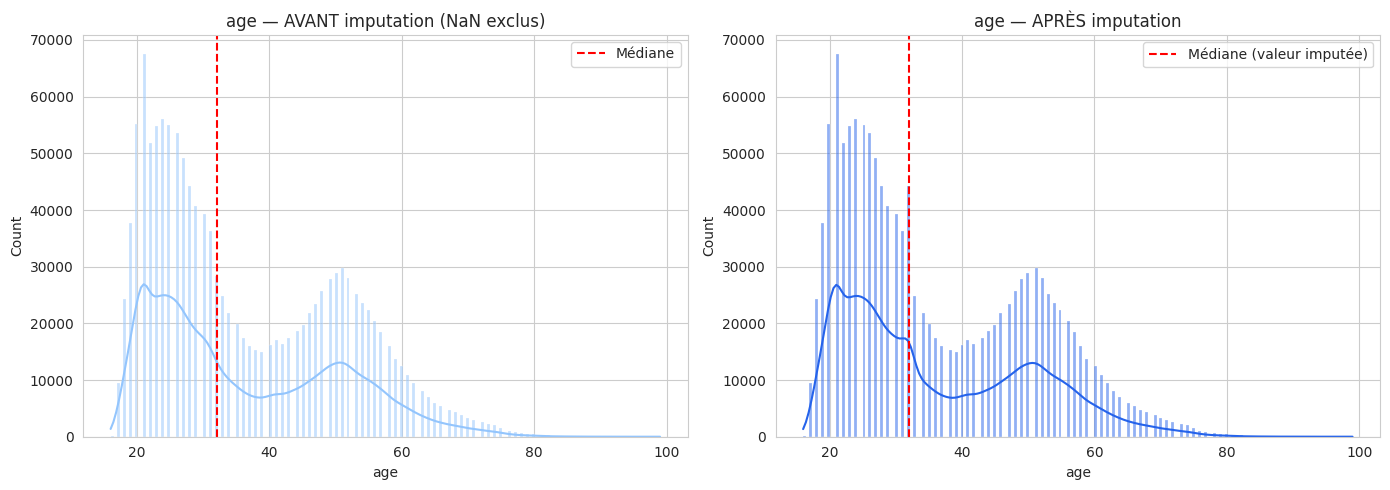

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["age"].dropna(), kde=True, ax=axes[0], color="#93c5fd")
axes[0].axvline(df["age"].median(), color="red", linestyle="--", label="Médiane")
axes[0].set_title("age — AVANT imputation (NaN exclus)")
axes[0].legend()

sns.histplot(customers["age"], kde=True, ax=axes[1], color="#2563eb")
axes[1].axvline(age_median, color="red", linestyle="--", label="Médiane (valeur imputée)")
axes[1].set_title("age — APRÈS imputation")
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close('all')


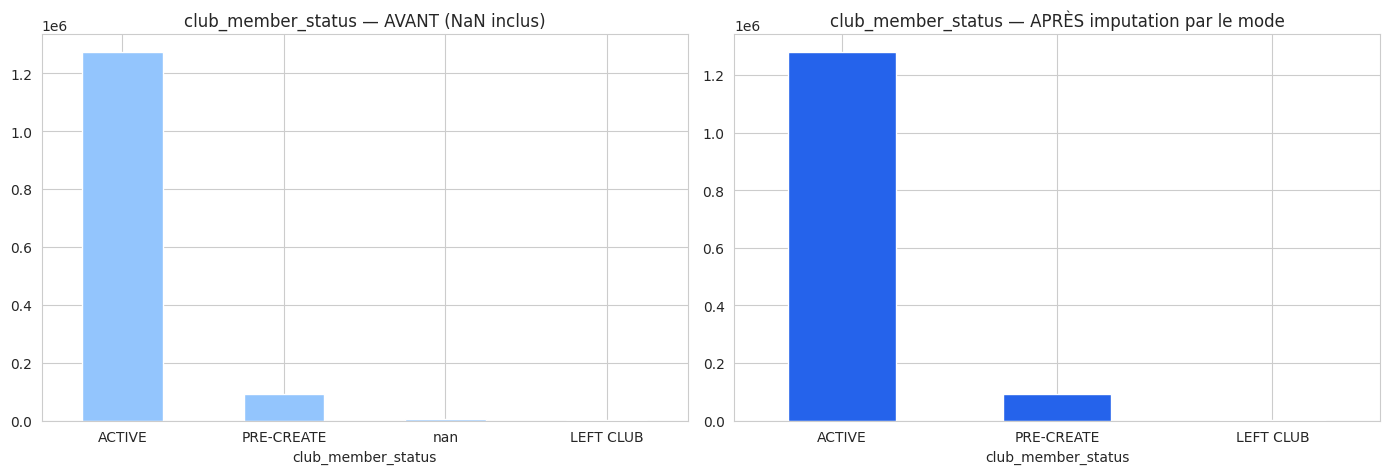

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["club_member_status"].value_counts(dropna=False).plot.bar(ax=axes[0], color="#93c5fd")
axes[0].set_title("club_member_status — AVANT (NaN inclus)")
axes[0].tick_params(axis='x', rotation=0)

customers["club_member_status"].value_counts().plot.bar(ax=axes[1], color="#2563eb")
axes[1].set_title("club_member_status — APRÈS imputation par le mode")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
plt.close('all')


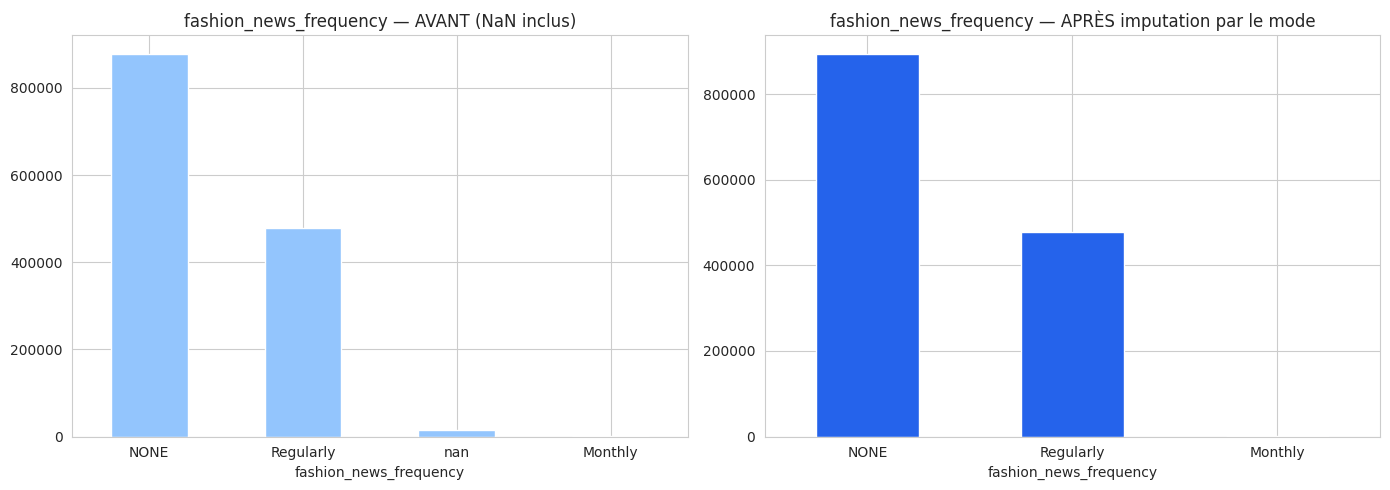

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["fashion_news_frequency"].value_counts(dropna=False).plot.bar(ax=axes[0], color="#93c5fd")
axes[0].set_title("fashion_news_frequency — AVANT (NaN inclus)")
axes[0].tick_params(axis='x', rotation=0)

customers["fashion_news_frequency"].value_counts().plot.bar(ax=axes[1], color="#2563eb")
axes[1].set_title("fashion_news_frequency — APRÈS imputation par le mode")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
plt.close('all')


**Remarque :** l'imputation par la médiane / le mode ne modifie pas la forme générale des distributions (les proportions relatives entre catégories restent quasi identiques, et l'histogramme de l'âge garde son asymétrie).

C'est justement l'intérêt de ces méthodes par rapport à une imputation par la moyenne, qui aurait légèrement déplacé le centre de la distribution vers la droite à cause de l'asymétrie.


## 4.2 Vérification finale du dataset nettoyé

In [24]:
print("Dimensions du dataset nettoyé :", customers.shape)
print()
customers.info()
print()
print("Valeurs manquantes restantes :", customers.isnull().sum().sum())
customers.describe(include="all").T


Dimensions du dataset nettoyé : (1371980, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371980 entries, 0 to 1371979
Data columns (total 5 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1371980 non-null  object 
 1   club_member_status      1371980 non-null  object 
 2   fashion_news_frequency  1371980 non-null  object 
 3   age                     1371980 non-null  float64
 4   postal_code             1371980 non-null  object 
dtypes: float64(1), object(4)
memory usage: 52.3+ MB

Valeurs manquantes restantes : 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1371980,1371980,ffffd9ac14e89946416d80e791d064701994755c3ab686...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
club_member_status,1371980,3,ACTIVE,1278553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fashion_news_frequency,1371980,3,NONE,893722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1371980.0,NaN,NaN,NaN,36.336248,14.238375,16.0,24.0,32.0,49.0,99.0
postal_code,1371980,352899,2c29ae653a9282cce4151bd87643c907644e09541abc28...,120303,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# Sauvegarde du dataset nettoyé
customers.to_csv("customers_cleaned.csv", index=False)
print("Fichier 'customers_cleaned.csv' sauvegardé avec succès.")


Fichier 'customers_cleaned.csv' sauvegardé avec succès.


## 5. Synthèse du nettoyage

- **`FN` et `Active`** : retirées (NaN = absence d'abonnement/activité, pas une vraie donnée manquante).
- **`age`** : distribution asymétrique (skew ≈ 0.61) et non normale (test D'Agostino-Pearson,
  p ≈ 0) → valeurs manquantes imputées par la **médiane**.
- **`club_member_status`** et **`fashion_news_frequency`** : variables catégorielles très
  déséquilibrées → valeurs manquantes imputées par le **mode** (`ACTIVE` et `NONE` respectivement).
- **`customer_id`** et **`postal_code`** : aucune valeur manquante, aucun traitement nécessaire.
- Le dataset nettoyé ne contient plus aucune valeur manquante et est exporté dans
  `customers_cleaned.csv`.


# 6. Exploration approfondie du dataset nettoyé

À partir d'ici, on travaille exclusivement sur `customers` (nettoyé, sans valeur manquante) pour analyser les profils clients et en tirer des interprétations business.


## 6.1 Répartition par tranche d'âge

In [26]:
bins = [16, 20, 25, 30, 35, 40, 50, 60, 70, 100]
labels = ['16-19', '20-24', '25-29', '30-34', '35-39', '40-49', '50-59', '60-69', '70+']
customers["age_group"] = pd.cut(customers["age"], bins=bins, labels=labels, right=False)

age_group_counts = customers["age_group"].value_counts().sort_index()
age_group_pct = (age_group_counts / len(customers) * 100).round(1)
pd.DataFrame({"count": age_group_counts, "pct": age_group_pct})


,count,pct
age_group,,
16-19,71583,5.2
20-24,285586,20.8
25-29,242772,17.7
30-34,166381,12.1
35-39,83548,6.1
40-49,204118,14.9
50-59,226242,16.5
60-69,72623,5.3
70+,19127,1.4


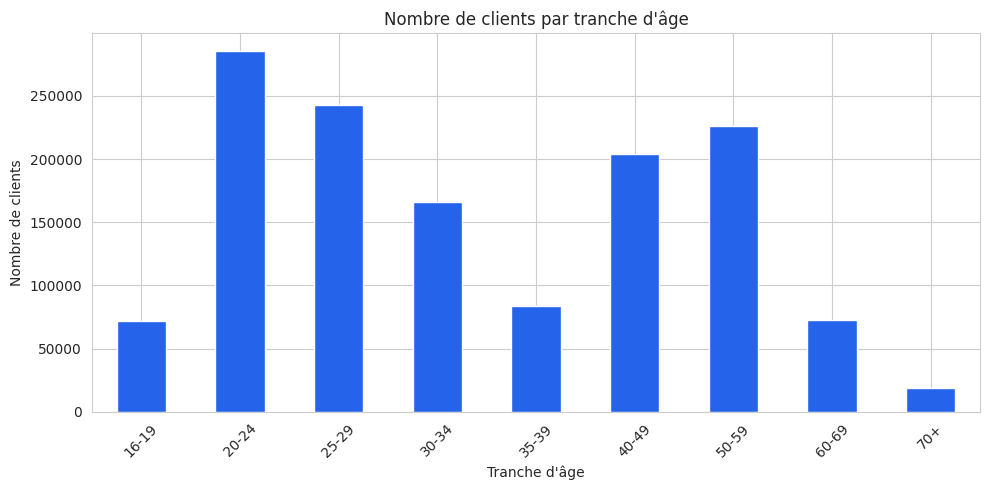

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
age_group_counts.plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("Nombre de clients par tranche d'âge")
ax.set_xlabel("Tranche d'âge")
ax.set_ylabel("Nombre de clients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close('all')


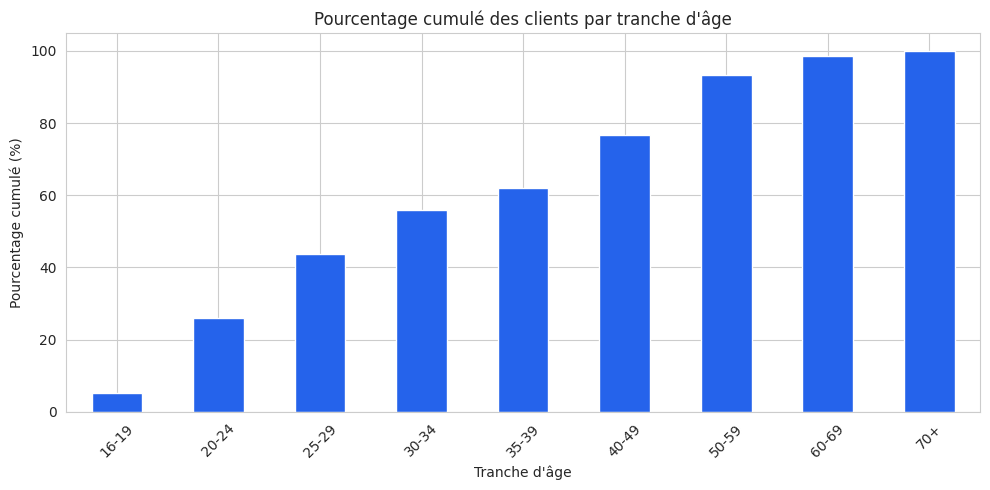

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

age_group_cum_pct = age_group_counts.cumsum() / age_group_counts.sum() * 100

age_group_cum_pct.plot(kind="bar", ax=ax, color="#2563eb")

ax.set_title("Pourcentage cumulé des clients par tranche d'âge")
ax.set_xlabel("Tranche d'âge")
ax.set_ylabel("Pourcentage cumulé (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :** les 20-34 ans représentent à eux seuls plus du **50%** de la base clients (20-24, 25-29 et 30-34 ans cumulés), ce qui est cohérent avec le positionnement mode/tendance de H&M.

Les 70 ans et plus sont très minoritaires (<1.5%). La base clients est donc structurellement jeune,
un point important pour cibler les campagnes marketing et les collections mises en avant.


## 6.2 Âge médian par statut club

In [29]:
age_by_status = customers.groupby("club_member_status")["age"].agg(["median", "mean", "count"]).round(1)
age_by_status


,median,mean,count
club_member_status,,,
ACTIVE,31.0,36.1,1278553
LEFT CLUB,29.0,34.0,467
PRE-CREATE,38.0,40.2,92960


| Observation                             | Signification                                                        |
| --------------------------------------- | -------------------------------------------------------------------- |
| ACTIVE a la plus grande population      | La majorité des données correspond à des membres engagés             |
| PRE-CREATE est plus âgé                 | Potentiel de conversion vers des membres actifs                      |
| LEFT CLUB est plus jeune                | Risque potentiel de churn chez les jeunes clients                    |
| Moyenne > médiane dans tous les groupes | Présence d'une population plus âgée qui tire la moyenne vers le haut |


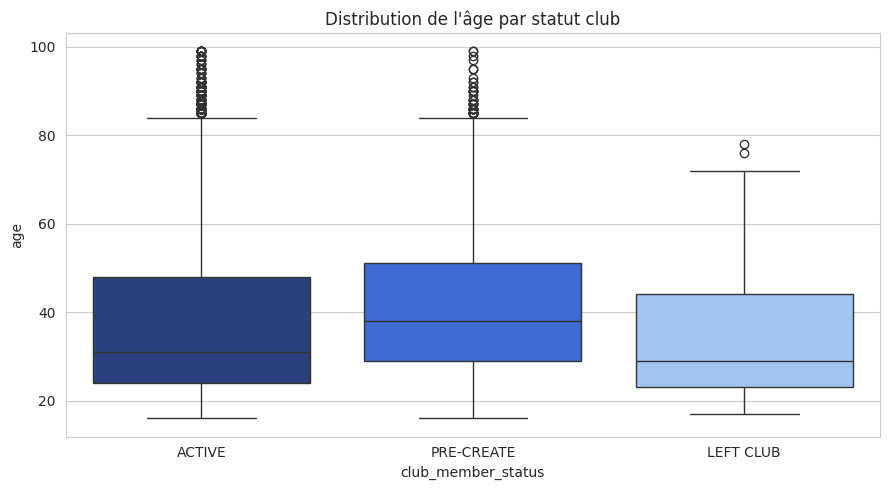

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=customers, x="club_member_status", y="age", ax=ax,
            palette=["#1e3a8a", "#2563eb", "#93c5fd"])
ax.set_title("Distribution de l'âge par statut club")
plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :** les clients en `PRE-CREATE` (compte créé mais pas encore membre officiel du club) ont un âge médian plus élevé (\~38 ans) que les membres `ACTIVE` (\~31 ans) ou ceux ayant quitté le club, `LEFT CLUB` (\~29 ans). Cela peut suggérer que les clients plus jeunes s'engagent plus vite dans le programme de fidélité, tandis que les clients plus âgés restent plus souvent en statut intermédiaire sans finaliser leur inscription.


## 6.3 Statut club par tranche d'âge (%)

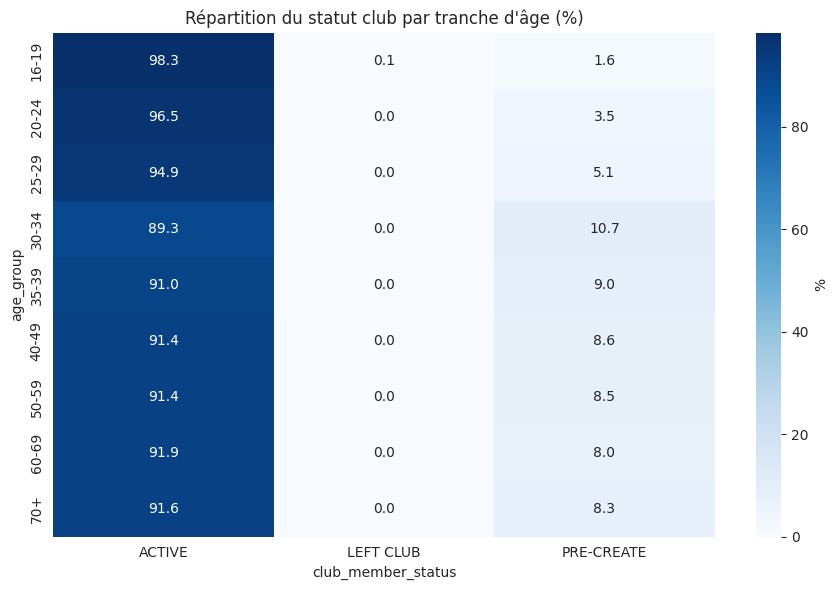

In [31]:
age_status_cross = pd.crosstab(customers["age_group"], customers["club_member_status"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(age_status_cross.round(1), annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "%"}, ax=ax)
ax.set_title("Répartition du statut club par tranche d'âge (%)")
plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :** la part de clients `ACTIVE` est très élevée (>94%) chez les moins de 30 ans,
puis diminue légèrement et se stabilise autour de 89-92% au-delà de 30 ans, au profit de `PRE-CREATE`
qui grimpe jusqu'à ~10-11% chez les 30-34 ans. `LEFT CLUB` reste anecdotique (≈0%) sur toutes les tranches, le taux de désabonnement visible dans cette variable est donc très faible dans l'absolu.


## 6.4 Fréquence des news mode par statut club

In [32]:
news_status_cross = pd.crosstab(customers["club_member_status"], customers["fashion_news_frequency"], normalize="index") * 100
news_status_cross.round(1)


fashion_news_frequency,Monthly,NONE,Regularly
club_member_status,,,
ACTIVE,0.1,63.1,36.9
LEFT CLUB,0.0,98.3,1.7
PRE-CREATE,0.1,93.7,6.2


| Observation                                   | Analyse                                                                                 |
| --------------------------------------------- | --------------------------------------------------------------------------------------- |
| ACTIVE possède le plus de `Regularly` (36.9%) | Les membres actifs sont davantage connectés aux campagnes marketing                     |
| LEFT CLUB a 98.3% de `NONE`                   | Forte absence d'engagement marketing avant le départ                                    |
| PRE-CREATE a très peu de newsletters          | Opportunité de conversion avec des campagnes d'activation                               |
| Monthly est presque inexistant                | H&M utilise probablement davantage une communication régulière qu'un abonnement mensuel |


La variable fashion_news_frequency peut être un bon indicateur d'engagement client :

- Regularly → pourrait être un signal positif pour prédire la fidélité.
- NONE → pourrait être associé à un risque de désengagement.

Combinée avec :
- nombre d'achats,
- récence du dernier achat,
- montant dépensé,
- catégories préférées,

elle peut améliorer un modèle de segmentation client, de prédiction du churn ou de recommandation personnalisée.

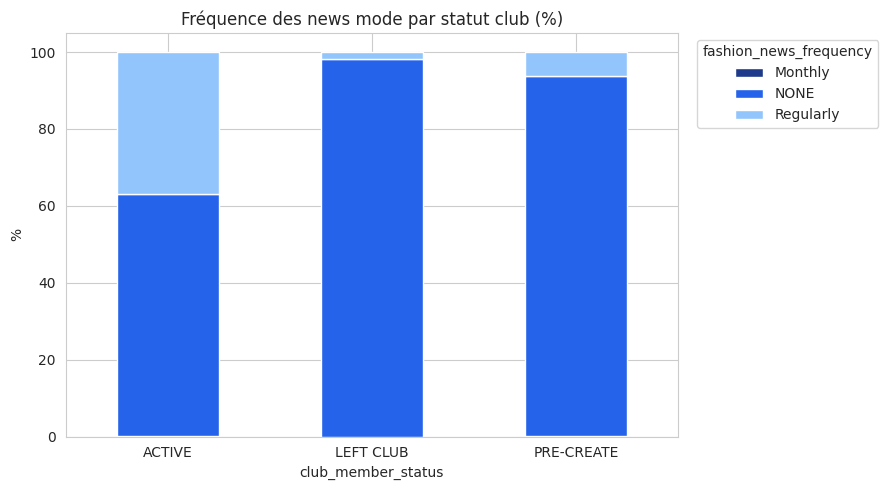

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))
news_status_cross.plot(kind="bar", stacked=True, ax=ax, color=["#1e3a8a", "#2563eb", "#93c5fd"])
ax.set_title("Fréquence des news mode par statut club (%)")
ax.set_ylabel("%")
plt.xticks(rotation=0)
plt.legend(title="fashion_news_frequency", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :** les membres `ACTIVE` sont ceux qui reçoivent le plus souvent des news mode
"Regularly", alors que `PRE-CREATE` et `LEFT CLUB` sont très majoritairement en `NONE`. Cela renforce
l'idée que l'engagement au programme de fidélité (statut club) et l'engagement marketing (news mode)
vont de pair : un client pleinement actif dans le club est aussi plus réceptif à la communication
mode de la marque.


## 6.5 Concentration géographique (`postal_code`)

In [34]:
top_postal = customers["postal_code"].value_counts().head(10)
top_postal_pct = (top_postal / len(customers) * 100).round(2)
pd.DataFrame({"count": top_postal, "pct": top_postal_pct})


,count,pct
postal_code,,
2c29ae653a9282cce4151bd87643c907644e09541abc28ae87dea0d1f6603b1c,120303,8.77
cc4ed85e30f4977dae47662ddc468cd2eec11472de6fac5ec985080fd92243c8,261,0.02
714976379549eb90aae4a71bca6c7402cc646ae7c40f6c1cb91d4b5a18623fc1,159,0.01
7c1fa3b0ec1d37ce2c3f34f63bd792f3b4494f324b6be5d1e4ba6a75456b96a7,157,0.01
5b7eb31eabebd3277de632b82267286d847fd5d44287ee150bb4206b48439145,156,0.01
1f5bd429acc88fbbf24de844a59e438704aa8761bc7b99fd977cad297c50b74c,154,0.01
9d5787501bf1c77592156ba51eab13f4a2670c807686431a9e22a69090b02358,141,0.01
a1959a16bf167858c93a66ec2a330644512b25fb10f97eee2058549885af4dbd,138,0.01
087a46b65170845b4a55226ff1eb748ce7843d4b637cbe17f6bfbd1e645d2ffb,134,0.01


In [35]:
top1_share = customers["postal_code"].value_counts(normalize=True).iloc[0] * 100
print(f"Le code postal le plus fréquent représente à lui seul {top1_share:.1f}% des clients.")
print(f"Nombre total de codes postaux distincts : {customers['postal_code'].nunique():,}")


Le code postal le plus fréquent représente à lui seul 8.8% des clients.
Nombre total de codes postaux distincts : 352,899


**Interprétation :** un seul code postal concentre à lui seul près de **9%** des clients, un ordre de grandeur totalement anormal comparé aux ~350 000 autres codes postaux qui se partagent le reste de
la base de façon beaucoup plus dispersée (quelques centaines de clients au maximum chacun).

Ce pic est très probablement un **code postal "par défaut"** utilisé par H&M lorsque l'adresse du client n'est pas renseignée ou pas valide, plutôt qu'une vraie zone de forte densité client.

À signaler comme point de vigilance pour toute analyse géographique ultérieure (ce code devrait être traité comme "inconnu" et exclu des analyses par zone).


## 6.6 Tableau de segmentation clients

In [36]:
segmentation = customers.pivot_table(
    index="age_group", columns="club_member_status", values="customer_id", aggfunc="count", observed=True
).fillna(0).astype(int)
segmentation["Total"] = segmentation.sum(axis=1)
segmentation


club_member_status,ACTIVE,LEFT CLUB,PRE-CREATE,Total
age_group,,,,
16-19,70400,37,1146,71583
20-24,275615,110,9861,285586
25-29,230282,93,12397,242772
30-34,148580,54,17747,166381
35-39,76017,35,7496,83548
40-49,186514,48,17556,204118
50-59,206847,65,19330,226242
60-69,66772,17,5834,72623
70+,17526,8,1593,19127


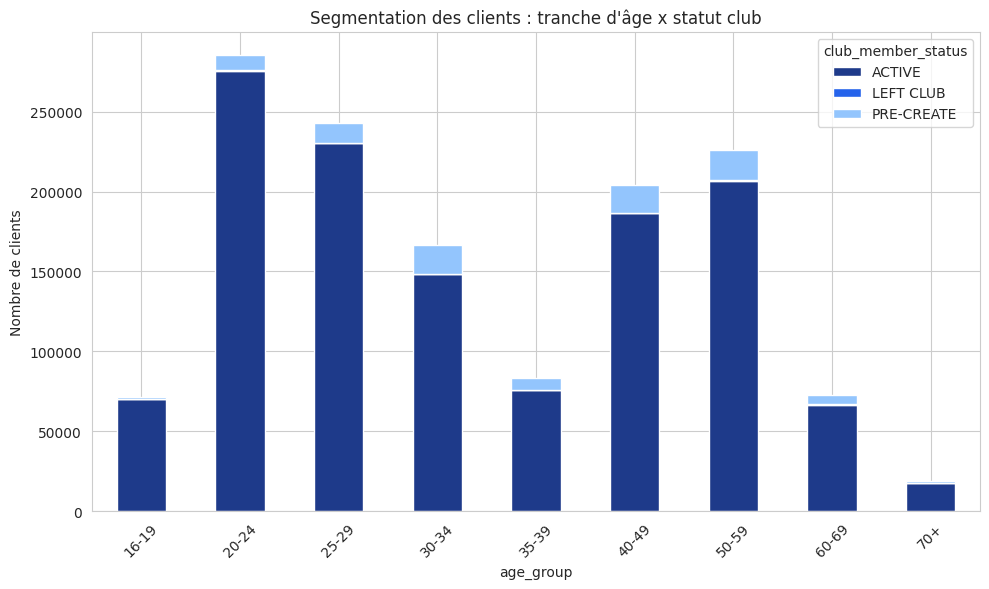

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
segmentation.drop(columns="Total").plot(kind="bar", stacked=True, ax=ax,
                                         color=["#1e3a8a", "#2563eb", "#93c5fd"])
ax.set_title("Segmentation des clients : tranche d'âge x statut club")
ax.set_ylabel("Nombre de clients")
plt.xticks(rotation=45)
plt.legend(title="club_member_status")
plt.tight_layout()
plt.show()
plt.close('all')


## 7. Synthèse finale et interprétation business

**Profil général de la base clients**
- ~1,37 million de clients uniques, sans doublon, base propre après nettoyage.
- Base clients **jeune** : plus de 50% ont entre 20 et 34 ans ; les seniors (70+) sont marginaux.
- Programme de fidélité très largement adopté : **~93%** des clients sont `ACTIVE`, le `LEFT CLUB`
  est quasi inexistant dans les données disponibles.

**Comportement d'engagement**
- L'engagement marketing (`fashion_news_frequency`) est corrélé au statut club : les clients `ACTIVE` reçoivent plus souvent des communications mode que les `PRE-CREATE`. Cela suggère un niveau d'engagement marketing potentiellement plus élevé chez les membres actifs.
- Lees profils `PRE-CREATE` présentent une population légèrement plus âgée en moyenne (âge médian ≈ 38 ans) que les profils `ACTIVE` (âge médian ≈ 31 ans). Cette différence peut indiquer une tendance selon laquelle les clients plus âgés sont davantage représentés parmi les comptes non finalisés, mais cette observation nécessite une analyse complémentaire avant d'en tirer une conclusion comportementale.

**Points de vigilance identifiés**
- `FN` et `Active` (retirées) sont très majoritairement non renseignées, leur usage réel dans H&M semble être un flag binaire "présent=1 / absent=NaN" plutôt qu'une vraie mesure quantitative.
- Un code postal unique concentre ~9% des clients, signe probable d'une valeur "par défaut" plutôt que d'une vraie concentration géographique à exclure des analyses géospatiales futures.
- Les proportions de catégories imputées (mode) étant déjà très majoritaires avant nettoyage, l'imputation n'introduit pas de biais significatif sur `club_member_status` et `fashion_news_frequency`.

**Recommandations pour la suite**
1. Croiser ce dataset avec `transactions` (si disponible) pour relier profil démographique et
   comportement d'achat réel (fréquence, panier moyen, catégories achetées).
2. Étudier `postal_code` uniquement après avoir isolé/exclu la valeur "par défaut" identifiée.
3. Utiliser la segmentation âge x statut club comme base pour des campagnes marketing ciblées
   (ex. relance des `PRE-CREATE` 30-49 ans vers une adhésion complète au club).


In [38]:
import pickle
INTERMEDIATE_DIR = os.path.join(BASE_PATH, "intermediate/")
os.makedirs(INTERMEDIATE_DIR, exist_ok=True)


## Export vers le notebook suivant

Sauvegarde de la table `customers` nettoyée (avec `age_group`) pour les notebooks 02, 03 et 04.

In [39]:
with open(os.path.join(INTERMEDIATE_DIR, "nb01_customers.pkl"), "wb") as f:
    pickle.dump(customers, f)
print(f"Export -> nb01_customers.pkl  ({customers.shape[0]:,} lignes x {customers.shape[1]} colonnes)")


Export -> nb01_customers.pkl  (1,371,980 lignes x 6 colonnes)
